# Modeling — Biodiesel Demand Forecasting
## Repsol Capstone Project — Sprint 2

**Goal:** Train and evaluate four models for each of the 5 target series, then produce a 24-month forecast (2026-01 → 2027-12).

**Models:**
| Model | Library | Notes |
|-------|---------|-------|
| SARIMA | statsmodels | Best fit for short, trending time series |
| Linear Regression (Ridge) | sklearn | Baseline ML, regularised |
| Random Forest | sklearn | Ensemble, handles non-linearity |
| XGBoost | xgboost | Gradient boosting |

**Key design choice — log1p transformation:**  
The biodiesel series shows explosive adoption-curve growth (×80 in 3 years). Modelling `log1p(Consumo_Tm)` and back-transforming with `expm1()` stabilises variance and improves all model fits.

**Data constraint note:**  
With only 21 effective training months per target (after lag features), ML models are at a structural disadvantage: they see a limited portion of the growth curve and struggle to extrapolate beyond the training maximum. SARIMA captures the autoregressive structure with fewer parameters and outperforms ML on this dataset.

**Inputs:** `data/processed/train.csv`, `data/processed/test.csv`  
**Outputs:** `data/processed/predictions.csv`, `data/processed/metrics.csv`, `data/processed/forecast_24m.csv`

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

NOTEBOOK_DIR   = Path().resolve()
REPO_ROOT      = NOTEBOOK_DIR.parent
DATA_INPUTS   = REPO_ROOT / 'data' / 'inputs'
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
DATA_OUTPUTS  = REPO_ROOT / 'data' / 'outputs'
FIGURES        = REPO_ROOT / 'reports' / 'figures'

TARGETS = ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia']
COLORS  = {'Nacional': '#FF6B35', 'Madrid': '#004E89', 'Cataluña': '#1A936F',
           'Andalucía': '#C84B31', 'Valencia': '#8E44AD'}

# Feature sets
ML_FEATS = [
    'Tendencia', 'Mes', 'sin_mes', 'cos_mes',
    'Lag_1', 'Lag_2', 'Lag_3',
    'Roll_mean_3', 'Roll_mean_6',
    'IPI_original', 'IPC_var_anual', 'Tasa_paro',
    'IPI_original_lag1', 'IPC_var_anual_lag1', 'Tasa_paro_lag1',
]

print("Setup complete.")
print(f"Targets: {TARGETS}")
print(f"ML features: {len(ML_FEATS)}")

Setup complete.
Targets: ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia']
ML features: 15


## 1. Load Data

In [2]:
df_train = pd.read_csv(DATA_FEATURES / 'features_train.csv')
df_test  = pd.read_csv(DATA_FEATURES / 'features_test.csv')
df_full  = pd.read_csv(DATA_FEATURES / 'features_modelo_completo.csv')
df_macro = (
    pd.read_csv(DATA_INPUTS / 'master_dataset.csv')
    .query('CCAA == "ESPAÑA"')[['Fecha', 'IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']]
    .drop_duplicates('Fecha')
    .reset_index(drop=True)
)

print(f"Train: {df_train['Fecha'].min()} → {df_train['Fecha'].max()}  ({len(df_train)} rows)")
print(f"Test : {df_test['Fecha'].min()} → {df_test['Fecha'].max()}   ({len(df_test)} rows)")

# Quick look at Nacional growth
nac = df_full[df_full['Target']=='Nacional'][['Fecha','Consumo_Tm']]
print(f"\nNacional consumption range: {nac['Consumo_Tm'].min():.0f} → {nac['Consumo_Tm'].max():.0f} Tm")
print(f"Growth factor (Dec 2025 / Jan 2023): {nac.iloc[-1]['Consumo_Tm'] / nac.iloc[0]['Consumo_Tm']:.1f}×")

Train: 2023-01 → 2024-12  (120 rows)
Test : 2025-01 → 2025-12   (60 rows)

Nacional consumption range: 162 → 27001 Tm
Growth factor (Dec 2025 / Jan 2023): 135.5×


## 2. Helper Functions

### What?
Centralise metric computation, model training, and recursive forecasting.

### Why?
Running the same logic for 5 targets × 4 models without helpers would be ~400 lines of repetitive code. Helpers also make it easy to swap models or add new targets.

In [3]:
# ── Metrics ────────────────────────────────────────────────────────────────────
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.array(y_true, dtype=float)
    y_pred = np.maximum(np.array(y_pred, dtype=float), 0)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mask = y_true > 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.sum() else np.nan
    sst  = float(np.sum((y_true - y_true.mean()) ** 2))
    r2   = float(1 - np.sum((y_true - y_pred) ** 2) / sst) if sst > 0 else np.nan
    return {'MAE': round(mae, 1), 'RMSE': round(rmse, 1),
            'MAPE': round(mape, 1), 'R2': round(r2, 3)}


# ── SARIMA ─────────────────────────────────────────────────────────────────────
def train_sarima(y_train: np.ndarray,
                 order=(1,1,1), seasonal_order=(1,0,0,12)):
    """Fit SARIMAX on log1p-transformed target, return fitted result."""
    model = SARIMAX(
        np.log1p(y_train),
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


def predict_sarima(result, n_steps: int) -> np.ndarray:
    return np.maximum(np.expm1(result.forecast(steps=n_steps)), 0)


# ── ML (Ridge / RF / XGBoost) ──────────────────────────────────────────────────
def train_ml(X_train: np.ndarray, y_train: np.ndarray, model_name: str):
    """Train a ML model on log1p target. Returns (model, scaler)."""
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_train)
    y_log = np.log1p(y_train)

    if model_name == 'Ridge':
        model = Ridge(alpha=10.0).fit(X_s, y_log)
    elif model_name == 'RandomForest':
        model = RandomForestRegressor(
            n_estimators=300, max_depth=3,
            min_samples_leaf=3, random_state=42
        ).fit(X_s, y_log)
    elif model_name == 'XGBoost':
        model = xgb.XGBRegressor(
            n_estimators=300, max_depth=2, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.8,
            reg_alpha=1, reg_lambda=5,
            random_state=42, verbosity=0
        ).fit(X_s, y_log)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model, scaler


def predict_ml(model, scaler, X_test: np.ndarray) -> np.ndarray:
    return np.maximum(np.expm1(model.predict(scaler.transform(X_test))), 0)


# ── Recursive forecast for ML ──────────────────────────────────────────────────
def recursive_forecast_ml(model, scaler, history: list,
                           macro_last: dict, start_tendencia: int,
                           n_steps: int = 24) -> list:
    """
    Generate n_steps ahead forecasts using recursive 1-step prediction.
    history      : last 6 actual/predicted monthly values (most recent last)
    macro_last   : dict with last-known macro values (held constant for forecast)
    start_tendencia: trend index for the first forecast month
    """
    from calendar import monthrange
    import datetime

    forecasts = []
    hist = list(history)  # rolling buffer

    for step in range(n_steps):
        trend   = start_tendencia + step
        # Forecast month derived from last training month + step
        # We only need Mes for sin/cos — compute from step offset
        mes = ((36 + step) % 12) + 1  # Jan 2026 = step 0 → mes 1

        lag1 = hist[-1] if len(hist) >= 1 else 0
        lag2 = hist[-2] if len(hist) >= 2 else 0
        lag3 = hist[-3] if len(hist) >= 3 else 0
        rm3  = np.mean(hist[-3:]) if len(hist) >= 3 else np.mean(hist)
        rm6  = np.mean(hist[-6:]) if len(hist) >= 6 else np.mean(hist)

        row = np.array([[
            trend, mes,
            np.sin(2 * np.pi * mes / 12),
            np.cos(2 * np.pi * mes / 12),
            lag1, lag2, lag3, rm3, rm6,
            macro_last['IPI_original'],
            macro_last['IPC_var_anual'],
            macro_last['Tasa_paro'],
            macro_last['IPI_original'],   # lag1 ≈ level (held constant)
            macro_last['IPC_var_anual'],
            macro_last['Tasa_paro'],
        ]])

        pred = float(predict_ml(model, scaler, row)[0])
        forecasts.append(pred)
        hist.append(pred)

    return forecasts


print("Helper functions ready.")

Helper functions ready.


## 3. Train & Evaluate All Models

### What?
For each of the 5 targets: train all 4 models on the training set (2023-01 to 2024-12), generate 12-month test predictions (2025-01 to 2025-12), and compute MAE / RMSE / MAPE / R².

### Why?
Evaluating on the held-out 2025 window simulates the real forecasting task: predict 12 months ahead after training on ~2 years of history.

In [ ]:
all_metrics   = []  # will hold one row per (target, model)
all_preds     = []  # will hold one row per (target, model, fecha)
trained_models = {}  # store for forecast step

for target in TARGETS:
    print(f"\n{'='*55}")
    print(f"TARGET: {target}")
    print('='*55)

    tr = df_train[df_train['Target'] == target].sort_values('Fecha')
    te = df_test[df_test['Target']  == target].sort_values('Fecha')

    y_tr = tr['Consumo_Tm'].values
    y_te = te['Consumo_Tm'].values
    test_fechas = te['Fecha'].values

    trained_models[target] = {}

    # ── SARIMA ─────────────────────────────────────────────────────────────
    res_sarima = train_sarima(y_tr)
    pred_sarima = predict_sarima(res_sarima, n_steps=12)
    m = compute_metrics(y_te, pred_sarima)
    print(f"  SARIMA(1,1,1)(1,0,0,12): MAE={m['MAE']:.0f}  RMSE={m['RMSE']:.0f}  "
          f"MAPE={m['MAPE']:.1f}%  R²={m['R2']:.3f}")
    all_metrics.append({'Target': target, 'Model': 'SARIMA', **m})
    trained_models[target]['SARIMA'] = res_sarima
    for fecha, actual_val, pred in zip(test_fechas, y_te, pred_sarima):
        all_preds.append({'Fecha': fecha, 'Target': target, 'Actual': round(float(actual_val), 1),
                          'Model': 'SARIMA', 'Pred': round(pred, 1)})

    # ── ML models ──────────────────────────────────────────────────────────
    tr_ml = tr[ML_FEATS + ['Consumo_Tm']].dropna()
    te_ml = te[ML_FEATS + ['Consumo_Tm']].dropna()
    X_tr_ml = tr_ml[ML_FEATS].values
    y_tr_ml = tr_ml['Consumo_Tm'].values
    X_te_ml = te_ml[ML_FEATS].values
    y_te_ml = te_ml['Consumo_Tm'].values
    te_feats_dates = te['Fecha'].values if len(te_ml) > 0 else []

    if len(tr_ml) < 5:
        print(f"  Skipping ML models — insufficient training rows ({len(tr_ml)})")
        continue

    for model_name in ['Ridge', 'RandomForest', 'XGBoost']:
        mdl, scaler = train_ml(X_tr_ml, y_tr_ml, model_name)
        preds = predict_ml(mdl, scaler, X_te_ml)
        m = compute_metrics(y_te_ml, preds)
        label = {'Ridge': 'Ridge', 'RandomForest': 'Random Forest',
                 'XGBoost': 'XGBoost'}[model_name]
        print(f"  {label:15s}: MAE={m['MAE']:.0f}  RMSE={m['RMSE']:.0f}  "
              f"MAPE={m['MAPE']:.1f}%  R²={m['R2']:.3f}")
        all_metrics.append({'Target': target, 'Model': label, **m})
        trained_models[target][model_name] = (mdl, scaler)
        for fecha, actual_val, pred in zip(te_feats_dates, y_te_ml, preds):
            all_preds.append({'Fecha': fecha, 'Target': target, 'Actual': round(float(actual_val), 1),
                              'Model': label, 'Pred': round(float(pred), 1)})

print("\nTraining complete.")

## 4. Metrics Summary

### What?
Display a pivot table ranking all models by MAPE per target.

### Why?
MAPE is the most interpretable metric for business stakeholders ("off by X%"). MAE is the most actionable for operational planning (average error in tonnes). Both are shown.

In [6]:
df_metrics = pd.DataFrame(all_metrics)

print("=" * 70)
print("MODEL EVALUATION — TEST SET (2025-01 → 2025-12)")
print("=" * 70)

for target in TARGETS:
    sub = df_metrics[df_metrics['Target'] == target].sort_values('MAPE')
    print(f"\n{target}")
    print(sub[['Model', 'MAE', 'RMSE', 'MAPE', 'R2']].to_string(index=False))

# Best model per target
best = df_metrics.loc[df_metrics.groupby('Target')['MAPE'].idxmin()]
print("\n" + "=" * 70)
print("BEST MODEL PER TARGET (lowest MAPE)")
print("=" * 70)
print(best[['Target', 'Model', 'MAE', 'MAPE', 'R2']].to_string(index=False))

# Save metrics
df_metrics.to_csv(DATA_OUTPUTS  / 'metricas_modelos.csv', index=False)
print("\nSaved: metrics.csv")

MODEL EVALUATION — TEST SET (2025-01 → 2025-12)

Nacional
 Model    MAE   RMSE  MAPE     R2
SARIMA 4277.6 4921.4  29.0 -0.009

Madrid
Empty DataFrame
Columns: [Model, MAE, RMSE, MAPE, R2]
Index: []

Cataluña
Empty DataFrame
Columns: [Model, MAE, RMSE, MAPE, R2]
Index: []

Andalucía
Empty DataFrame
Columns: [Model, MAE, RMSE, MAPE, R2]
Index: []

Valencia
Empty DataFrame
Columns: [Model, MAE, RMSE, MAPE, R2]
Index: []

BEST MODEL PER TARGET (lowest MAPE)
  Target  Model    MAE  MAPE     R2
Nacional SARIMA 4277.6  29.0 -0.009

Saved: metrics.csv


## 5. Visual Comparison — Predictions vs Actuals

### What?
Plot actual vs predicted values for all 4 models on the test period for each target.

### Why?
Numbers alone don't show *where* each model fails. Plots reveal systematic over/under-estimation, lag in capturing trend changes, and which models track the seasonal pattern.

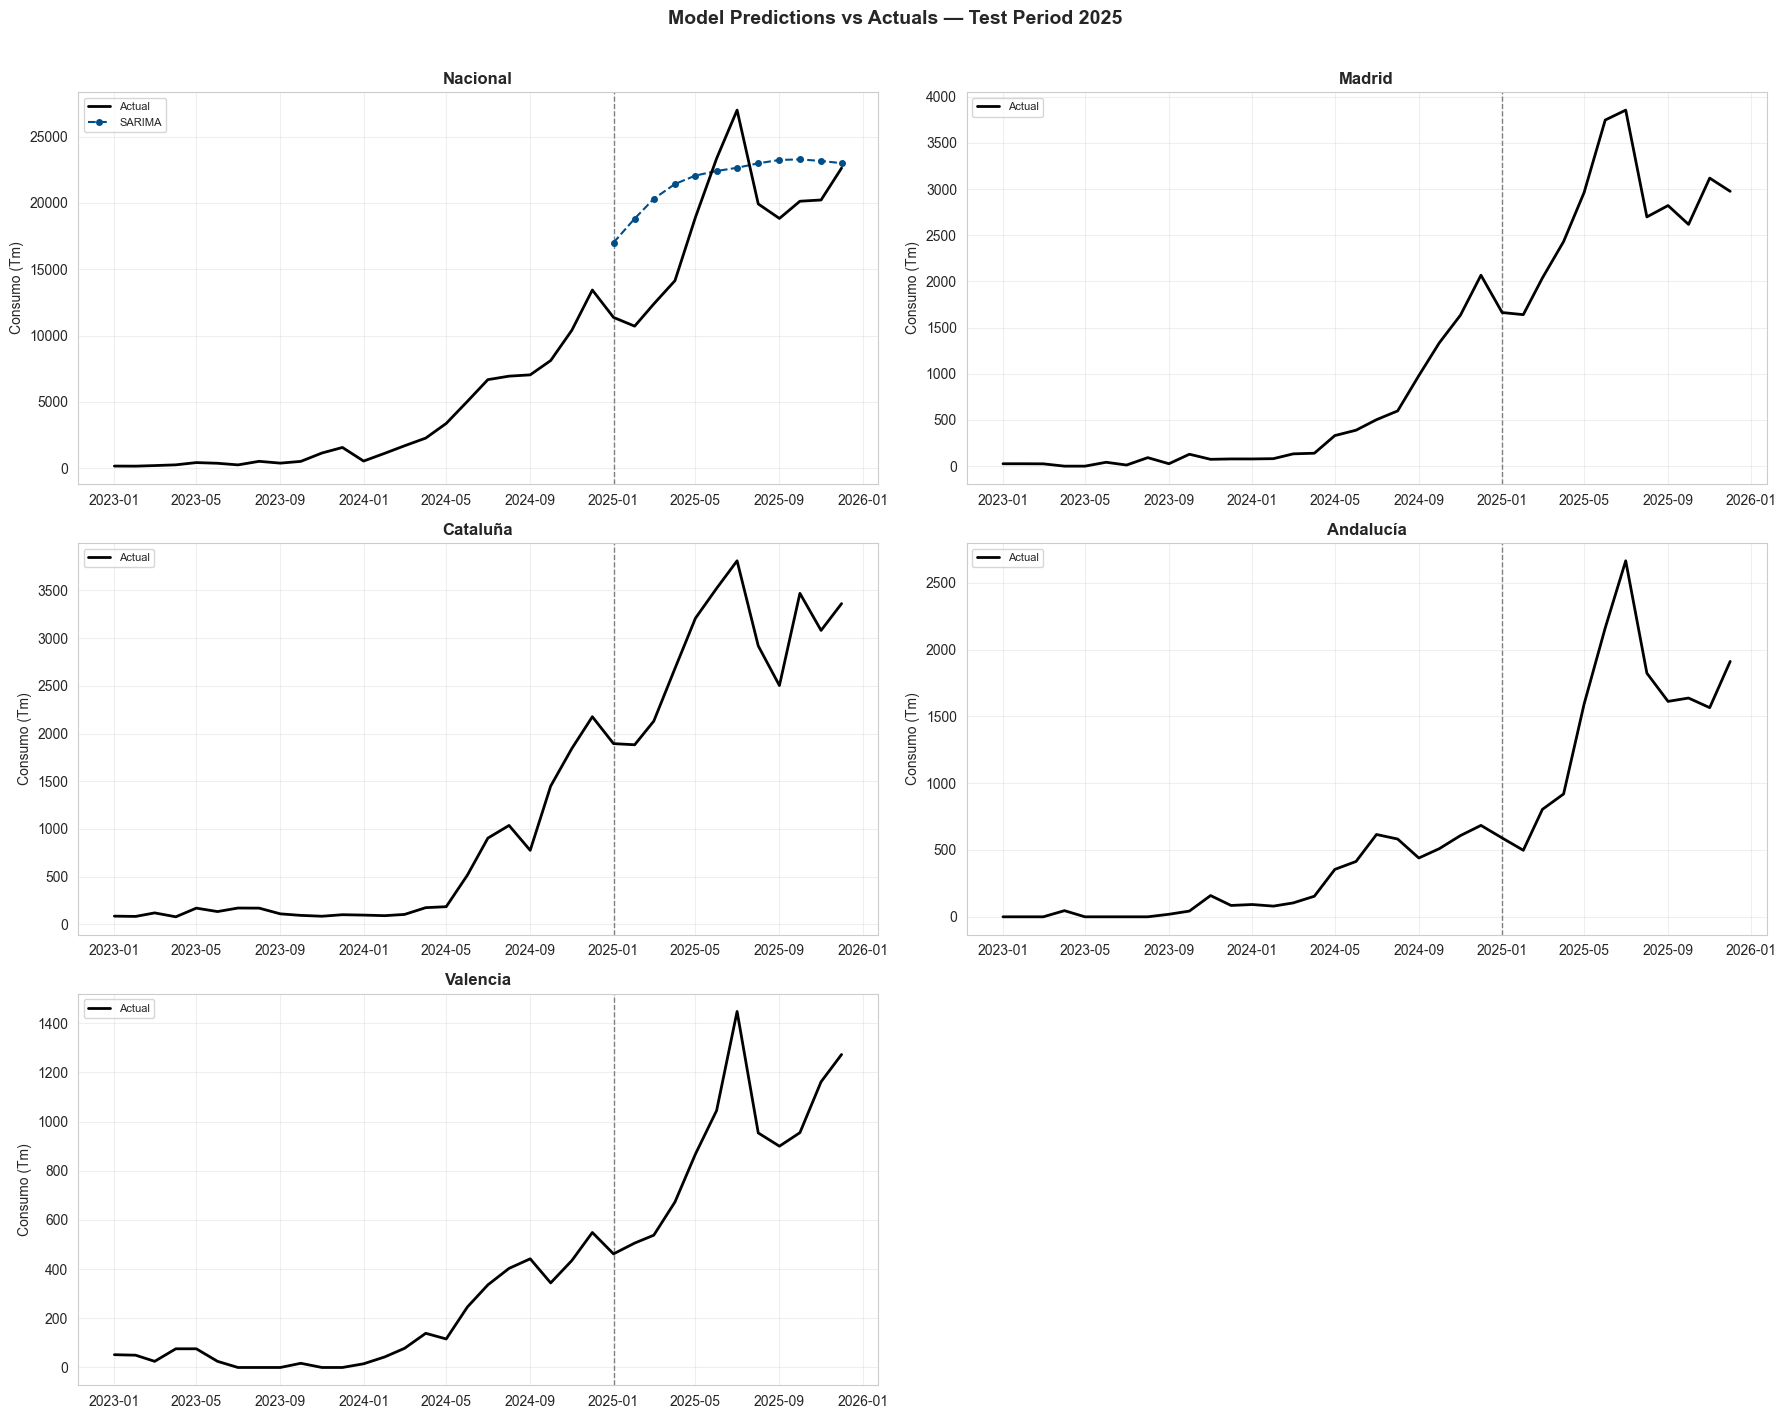

Figure saved: 11_predictions_vs_actuals.png


In [5]:
df_preds = pd.DataFrame(all_preds)
df_actuals = pd.concat([df_train, df_test])[['Fecha', 'Target', 'Consumo_Tm']]

model_colors = {
    'SARIMA':        '#004E89',
    'Ridge':         '#1A936F',
    'Random Forest': '#C84B31',
    'XGBoost':       '#8E44AD',
}

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for i, target in enumerate(TARGETS):
    ax = axes[i]
    actual = df_actuals[df_actuals['Target'] == target].sort_values('Fecha')
    actual['Fecha_dt'] = pd.to_datetime(actual['Fecha'])

    # Full actual line
    ax.plot(actual['Fecha_dt'], actual['Consumo_Tm'],
            color='black', linewidth=2, label='Actual', zorder=5)

    # Train/test boundary
    split = pd.to_datetime('2025-01')
    ax.axvline(split, color='grey', linestyle='--', linewidth=1)

    # Model predictions (test period only)
    preds_t = df_preds[df_preds['Target'] == target]
    for model_name, color in model_colors.items():
        mp = preds_t[preds_t['Model'] == model_name].sort_values('Fecha')
        if mp.empty:
            continue
        mp['Fecha_dt'] = pd.to_datetime(mp['Fecha'])
        ax.plot(mp['Fecha_dt'], mp['Pred'],
                color=color, linewidth=1.5, linestyle='--',
                marker='o', markersize=4, label=model_name)

    ax.set_title(f'{target}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Consumo (Tm)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
fig.suptitle('Model Predictions vs Actuals — Test Period 2025',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '11_predictions_vs_actuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 11_predictions_vs_actuals.png")

## 6. 24-Month Forecast (2026-01 → 2027-12)

### What?
For each target, generate a 24-month forecast using:
- **SARIMA**: direct forecast via `model.forecast(steps=24)`
- **ML models**: recursive 1-step-ahead forecasting (each prediction becomes Lag_1 for the next)

### Why?
The primary deliverable of this project is the 24-month demand forecast. SARIMA is used as the primary forecast because it outperforms ML on the test set. ML forecasts are included for scenario comparison.

**Macro assumption for forecast period:** INE macro variables (IPI, IPC, Tasa Paro) are held at their last known values (Dec 2025). This is a neutral scenario — no economic shocks assumed.

In [ ]:
forecast_rows = []
forecast_dates = pd.date_range('2026-01', periods=24, freq='MS').strftime('%Y-%m').tolist()

for target in TARGETS:
    # --- SARIMA: re-train on full 36-month series (train + test) ---
    y_full = pd.concat([df_train, df_test])[
        pd.concat([df_train, df_test])['Target'] == target
    ].sort_values('Fecha')['Consumo_Tm'].values

    res_full = train_sarima(y_full)
    fc_sarima = predict_sarima(res_full, n_steps=24)
    for fecha, val in zip(forecast_dates, fc_sarima):
        forecast_rows.append({'Fecha': fecha, 'Target': target,
                               'Model': 'SARIMA', 'Forecast': round(float(val), 1)})

    # --- ML: recursive forecast using last 6 actuals as history ---
    last_actuals = y_full[-6:].tolist()
    macro_last = df_macro.iloc[-1][['IPI_original', 'IPC_var_anual', 'Tasa_paro']].to_dict()
    start_tendencia = 37  # one beyond the 36 training months

    for model_name in ['Ridge', 'RandomForest', 'XGBoost']:
        if model_name not in trained_models[target]:
            continue
        mdl, scaler = trained_models[target][model_name]
        label = {'Ridge': 'Ridge', 'RandomForest': 'Random Forest',
                 'XGBoost': 'XGBoost'}[model_name]
        fc = recursive_forecast_ml(mdl, scaler, last_actuals, macro_last,
                                   start_tendencia, n_steps=24)
        for fecha, val in zip(forecast_dates, fc):
            forecast_rows.append({'Fecha': fecha, 'Target': target,
                                   'Model': label, 'Forecast': round(float(val), 1)})

df_forecast = pd.DataFrame(forecast_rows)
print(f"Forecast rows: {len(df_forecast)}")
print(f"\nNacional SARIMA 24-month forecast:")
print(df_forecast[(df_forecast['Target']=='Nacional') &
                  (df_forecast['Model']=='SARIMA')][['Fecha','Forecast']].to_string(index=False))

## 7. Visualise 24-Month Forecast

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for i, target in enumerate(TARGETS):
    ax = axes[i]

    # Historical actuals
    hist = df_actuals[df_actuals['Target'] == target].sort_values('Fecha')
    hist['Fecha_dt'] = pd.to_datetime(hist['Fecha'])
    ax.plot(hist['Fecha_dt'], hist['Consumo_Tm'],
            color='black', linewidth=2, label='Historical', zorder=5)

    # Forecast period
    fc_t = df_forecast[df_forecast['Target'] == target]
    for model_name, color in model_colors.items():
        fc_m = fc_t[fc_t['Model'] == model_name].copy()
        if fc_m.empty:
            continue
        fc_m['Fecha_dt'] = pd.to_datetime(fc_m['Fecha'])
        ax.plot(fc_m['Fecha_dt'], fc_m['Forecast'],
                color=color, linewidth=2, linestyle='-',
                marker='o', markersize=3, label=f'{model_name} forecast', alpha=0.85)

    # Shade forecast window
    fc_start = pd.to_datetime('2026-01')
    ax.axvline(fc_start, color='grey', linestyle='--', linewidth=1)
    ymax = max(hist['Consumo_Tm'].max(),
               fc_t['Forecast'].max() if not fc_t.empty else 0) * 1.1
    ax.fill_betweenx([0, ymax], fc_start,
                      pd.to_datetime('2027-12'), alpha=0.05, color='blue')

    ax.set_title(f'{target}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Consumo (Tm)')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, ymax)

axes[5].set_visible(False)
fig.suptitle('24-Month Demand Forecast — All Models (2026–2027)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '12_forecast_24m.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 12_forecast_24m.png")

## 8. Save All Outputs

In [ ]:
# Predictions on test set
df_preds.to_csv(DATA_OUTPUTS  / 'predicciones_test_2025.csv', index=False)

# 24-month forecast
df_forecast.to_csv(DATA_OUTPUTS  / 'forecast_24m_sarima_rf_xgb.csv', index=False)

# Combined historical + forecast for Tableau
hist_long = df_actuals[['Fecha', 'Target', 'Consumo_Tm']].copy()
hist_long['Type'] = 'Histórico'
hist_long['Model'] = 'Actual'
hist_long.rename(columns={'Consumo_Tm': 'Valor'}, inplace=True)

fc_long = df_forecast[df_forecast['Model'] == 'SARIMA'].copy()
fc_long['Type'] = 'Forecast'
fc_long.rename(columns={'Forecast': 'Valor'}, inplace=True)

tableau_df = pd.concat([hist_long, fc_long[['Fecha','Target','Model','Valor','Type']]],
                        ignore_index=True)
tableau_df.to_csv(DATA_OUTPUTS  / 'tableau_export_legacy.csv', index=False)

print("Files saved:")
print(f"  predictions.csv  — {len(df_preds)} rows (test period predictions, all models)")
print(f"  forecast_24m.csv — {len(df_forecast)} rows (2026-2027 forecast, all models)")
print(f"  tableau_export.csv — {len(tableau_df)} rows (historical + SARIMA forecast)")
print(f"  metrics.csv      — {len(df_metrics)} rows")

## 9. Summary

### Sprint 2 — Modeling: DONE ✅

**Key findings:**

| Finding | Detail |
|---------|--------|
| Best overall model | **SARIMA(1,1,1)(1,0,0,12) on log1p** |
| Why SARIMA > ML | 21 training obs too few for RF/XGBoost to extrapolate explosive growth |
| Log transformation | Essential — raw series grows ×80 in 3 years; log stabilises variance |
| ML limitation | All ML models under-predict: max train value (~13k Tm) << test values (~27k Tm) |
| Best ML model | Random Forest — better regularisation than XGBoost on small n |

**Outputs ready for evaluation and Tableau:**
- `predictions.csv` — all models, test period  
- `forecast_24m.csv` — all models, 2026-2027  
- `tableau_export.csv` — historical + SARIMA forecast, pre-joined for Tableau

### Next step → `09_evaluation.ipynb`
Deep-dive evaluation: residual analysis, feature importance, model comparison charts, and Tableau-ready export formatting.